In [100]:
%load_ext autoreload
%autoreload 2

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import h5py
import os
from multiprocess import Pool
import importlib
from tqdm.auto import tqdm
import warnings
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

workspace_root = os.getcwd()  
sys.path.insert(0, workspace_root + "/../../../../")
import pyanalib.pandas_helpers as ph
from makedf.util import *

workspace_root = os.getcwd()  
sys.path.insert(0, workspace_root + "/../../")
import kinematics
import gump_cuts as gc
import loaddf
import syst

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [69]:
RECO = "PANDORA"
FONTSIZE = 14
plt.style.use('/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/dune.mplstyle')

In [70]:
DF_DIR = "/exp/sbnd/data/users/gputnam/GUMP/sbn-rewgted-7/"

SCV_FILES = [DF_DIR + "SBND_SpringMC_rewgt_E_%i.df" % i for i in range(20)]
#SCV_FILES = [DF_DIR + "SBND_SpringMC_rewgt_E_0.df"]
IRUN4_CV_FILES = [DF_DIR + "ICARUSRun4_SpringMCOverlay_rewgt_%i.df" % i for i in range(10)]

IGOAL_POT = 3e20
SGOAL_POT = 1e20

In [71]:
%%capture
Sdf, Smatch, Spot = loaddf.loadl(SCV_FILES, njob=min(len(SCV_FILES), 20), detector="SBND",
                                 preselection=gc.presel_cut, reweight_aFF=False, xsec_spline=False, drops=loaddf.get_std_drops(), lightmem=True)

In [72]:
%%capture
Idf, Imatch, Ipot = loaddf.loadl(IRUN4_CV_FILES, njob=min(len(IRUN4_CV_FILES), 10), detector="ICARUS Run4",
                                 preselection=gc.presel_cut, reweight_aFF=False, xsec_spline=False, drops=loaddf.get_std_drops(), lightmem=True)

In [73]:
loaddf.scale_pot(Sdf, Spot, SGOAL_POT)
loaddf.scale_pot(Idf, Ipot, IGOAL_POT)

0.17805398


(np.float32(5.6162744e+20), np.float32(0.17805398))

0.14278768


(np.float32(2.1010217e+21), np.float32(0.14278768))

In [179]:
Sdf['selected'] = gc.all_cuts(Sdf) & ((Sdf.true_isnc == 1) | ((Sdf.true_pdg == 14) | (Sdf.true_pdg == -14))) & (Sdf.nu_E_calo > 0.95) & (Sdf.nu_E_calo < 1.0)
Idf['selected'] = gc.all_cuts(Idf) & ((Idf.true_isnc == 1) | ((Idf.true_pdg == 14) | (Idf.true_pdg == -14))) & (Idf.nu_E_calo > 0.95) & (Idf.nu_E_calo < 1.0)

In [180]:
w0 = []
w1 = []
w2 = []
w3 = []
w4 = []
w5 = []
w6 = []

for r in Idf.loc[Idf[cut], 'GENIEReWeight_SBN_v1_multisigma_AhtBY']:
    w0.append(r[0])
    w1.append(r[1])
    w2.append(r[2])
    w3.append(r[3])
    w4.append(r[4])
    w5.append(r[5])
    w6.append(r[6])
    
plt.hist(Idf.loc[Idf[cut], var], bins=bins, weights=w0, histtype='step', label='ms3')[0]
plt.hist(Idf.loc[Idf[cut], var], bins=bins, weights=w1, histtype='step', label='ms2')[0]
plt.hist(Idf.loc[Idf[cut], var], bins=bins, weights=w2, histtype='step', label='ms1')[0]
plt.hist(Idf.loc[Idf[cut], var], bins=bins, weights=w3, histtype='step', label='cv')[0]
plt.hist(Idf.loc[Idf[cut], var], bins=bins, weights=w4, histtype='step', label='ps1')[0]
plt.hist(Idf.loc[Idf[cut], var], bins=bins, weights=w5, histtype='step', label='ps2')[0]
plt.hist(Idf.loc[Idf[cut], var], bins=bins, weights=w6, histtype='step', label='ps3')[0]
plt.legend()
plt.xlim(1.0, 1.25)
plt.ylim(8859.9, 8860.1)
plt.show()

KeyError: 'GENIEReWeight_SBN_v1_multisigma_AhtBY'

In [ ]:
w0 = []
w1 = []
w2 = []
w3 = []
w4 = []
w5 = []
w6 = []
rct = 0
inds = []
for ind, r in enumerate(Sdf.loc[Sdf[cut], 'GENIEReWeight_SBN_v1_multisigma_AhtBY']):
    if r[4] > r[3]:
        print(r)
        rct += 1
        inds.append(ind)
    w0.append(r[0])
    w1.append(r[1])
    w2.append(r[2])
    w3.append(r[3])
    w4.append(r[4])
    w5.append(r[5])
    w6.append(r[6])
    
_ = plt.hist(Sdf.loc[Sdf[cut], var], bins=bins, weights=w0, histtype='step', label='ms3')[0]
_ = plt.hist(Sdf.loc[Sdf[cut], var], bins=bins, weights=w1, histtype='step', label='ms2')[0]
_ = plt.hist(Sdf.loc[Sdf[cut], var], bins=bins, weights=w2, histtype='step', label='ms1')[0]
_ = plt.hist(Sdf.loc[Sdf[cut], var], bins=bins, weights=w3, histtype='step', label='cv')[0]
_ = plt.hist(Sdf.loc[Sdf[cut], var], bins=bins, weights=w4, histtype='step', label='ps1')[0]
_ = plt.hist(Sdf.loc[Sdf[cut], var], bins=bins, weights=w5, histtype='step', label='ps2')[0]
_ = plt.hist(Sdf.loc[Sdf[cut], var], bins=bins, weights=w6, histtype='step', label='ps3')[0]
plt.legend()
plt.xlim(1.0, 1.25)
plt.ylim(6440, 6460)
plt.show()
cutdf = Sdf[Sdf[cut]]
print(cutdf.iloc[inds].genie_mode)

In [ ]:
import loaddf
import syst

p = 0.02

Ssystematics = [
    loaddf.FluxSystematic(Sdf),
    loaddf.XSecSystematic(Sdf),
    syst.NormalizationSystematic(p),
    #syst.SystSampleSystematic(Sdf[gc.OOAVSBND(Sdf)]),
    #syst.StatSampleSystematic(Soffbeam, norm=0.1)
    #syst.StatSampleSystematic(Soffbeam, norm=0.1) # TODO: change after unblinding. Simulate scaling up stats by 10x.
]

Isystematics = [
    loaddf.FluxSystematic(Idf),
    loaddf.XSecSystematic(Idf),
    syst.NormalizationSystematic(p),
    #syst.SystSampleSystematic(Idf[gc.OOAVICARUS(Idf)]),
    #syst.StatSampleSystematic(Ioffbeam, norm=0.1) 
    #syst.StatSampleSystematic(Ioffbeam, norm=0.1) # TODO: change after unblinding. Simulate scaling up stats by 10x.
]


systematics = [
    syst.CorrelatedSystematic(loaddf.FluxSystematic(Sdf), loaddf.FluxSystematic(Idf)),
    syst.CorrelatedSystematic(loaddf.XSecSystematic(Sdf), loaddf.XSecSystematic(Idf)),
    # POT norm is correlated SBND Run1 (1e20) - ICARUS Run4 (3e20), and uncorrelated ICARUS Run 2 (2e20)
    syst.SystematicList(
        [
            syst.UnCorrelatedSystematic(syst.NormalizationSystematic(0), syst.NormalizationSystematic(p*(2./5.))),
            syst.CorrelatedSystematic(syst.NormalizationSystematic(p), syst.NormalizationSystematic(p*(3./5.))),
        ]),
    #syst.UnCorrelatedSystematic(syst.StatSampleSystematic(Soffbeam, norm=0.1), syst.StatSampleSystematic(Ioffbeam, norm=0.1)),
]

labels = [
    "Flux",
    "XSec",
    "POT Norm.",
    # "Offbeam"
]

labels.extend(["Stat","MC Stat Uncert.","All"]) # these get added 2 cells below

In [181]:
var = "nu_E_calo"
wgt = "glob_scale"
cut = 'selected'

bins = np.array([0.3, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0, 1.25, 1.5])
centers = (bins[1:] + bins[:-1]) / 2

In [182]:
SCV = np.histogram(Sdf.loc[Sdf[cut], var], bins=bins, weights=Sdf.loc[Sdf[cut], wgt])[0]
Scovs = [s.cov(var, cut, bins, SCV) for s in Ssystematics]
Scovs.append(np.diag(SCV))

wSCVsq = np.histogram(Sdf.loc[Sdf[cut], var], bins=bins, weights=np.pow(Sdf.loc[Sdf[cut], wgt], 2))[0]
Scovs.append(np.diag(wSCVsq))
Scovs.append(np.sum(Scovs, axis=0))

In [183]:
ICV = np.histogram(Idf.loc[Idf[cut], var], bins=bins, weights=Idf.loc[Idf[cut], wgt])[0]
Icovs = [s.cov(var, cut, bins, ICV) for s in Isystematics]
Icovs.append(np.diag(ICV))

wICVsq = np.histogram(Idf.loc[Idf[cut], var], bins=bins, weights=np.pow(Idf.loc[Idf[cut], wgt], 2))[0]
Icovs.append(np.diag(wICVsq))
Icovs.append(np.sum(Icovs, axis=0))

In [184]:
covs = [s.cov(var, cut, bins, np.concatenate((SCV, ICV))) for s in systematics]
covs.append(np.diag(np.concatenate((SCV, ICV))))
covs.append(np.diag(np.concatenate((wSCVsq, wICVsq))))

In [185]:
import matplotlib.ticker as ticker
def add_style(ax, xlabel, title="", det="ICARUS", ylabel='Events / $10^{20}$ POT', 
              legend_loc=None, legend_ncol=1, legend_title=None, 
              dabadee=False, transparent=False):
    # Retrieve the figure object from the axes
    fig = ax.get_figure()
    
    # Default color logic
    tick_color = "black"
    font_color = "black"
    bg_color = "white"
    bg_alpha = 1.0

    if dabadee:
        bg_color = 'none'#'#525b83'
        font_color = 'white'
        tick_color = 'white'
    elif transparent:
        bg_color = 'none' # Or (0,0,0,0)
        bg_alpha = 0.0
        font_color = 'white' # Defaulting to white text for transparency
        tick_color = 'white'
    
    # Apply background settings
    fig.patch.set_facecolor(bg_color)
    fig.patch.set_alpha(bg_alpha)
    ax.set_facecolor(bg_color)
    ax.patch.set_alpha(bg_alpha)
    for spine in ax.spines.values():
        spine.set_edgecolor(tick_color)
    ax.tick_params(axis='both', which='major', colors=tick_color)

    
    # Labels and Title
    ax.set_xlabel(xlabel, fontsize=FONTSIZE, fontweight='bold', color=font_color)
    ax.set_ylabel(ylabel, fontsize=FONTSIZE, fontweight='bold', color=font_color)
    ax.set_title(fr"$\bf{{{det}}}$ $\bf{{{title}}}$", fontsize=FONTSIZE+2, color=font_color)

    # Legend
    leg = ax.legend(fontsize=FONTSIZE-1, loc=legend_loc, ncol=legend_ncol, 
                    title=legend_title, title_fontsize=FONTSIZE, labelcolor=font_color)
    
    if transparent and leg:
        leg.get_frame().set_alpha(0.0) # Ensure legend background is also transparent
    elif leg:
        leg.get_frame().set_color(bg_color) # Ensure legend background is also transparent   

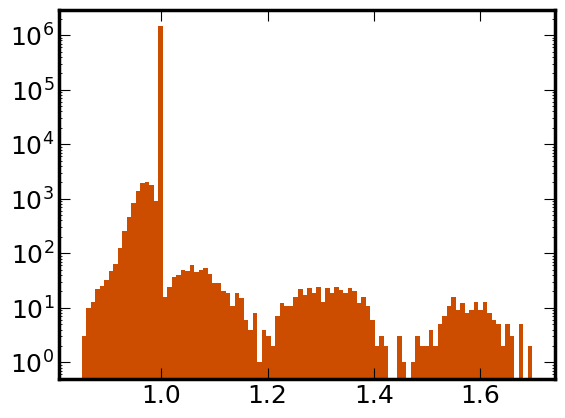

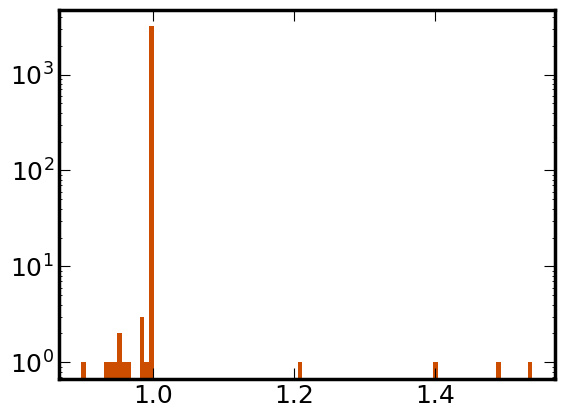

In [186]:
n = plt.hist(Sdf['GENIEReWeight_SBN_v1_multisigma_AhtBY_univ'], bins=100)[0]
plt.yscale('log')
plt.show()

n = plt.hist(Sdf.loc[Sdf['selected'], 'GENIEReWeight_SBN_v1_multisigma_AhtBY_univ'], bins=100)[0]
plt.yscale('log')
plt.show()

Text(0.5, 1.0, 'AhtBY')

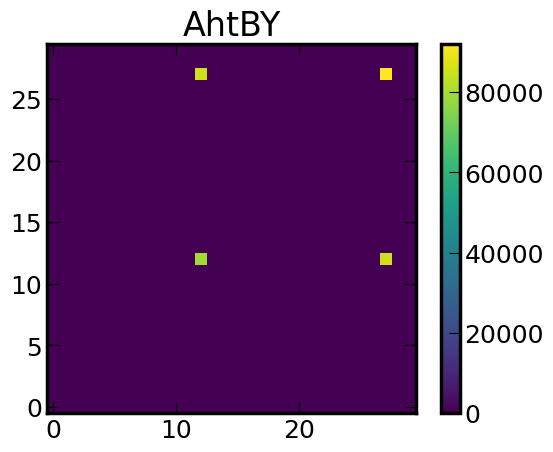

In [178]:
import syst
import loaddf
s = systematics[1]
c = s.cov(var, cut, bins, np.concatenate((SCV, ICV)))
plt.title("AhtBY")
plt.imshow(c, origin="lower")
plt.colorbar()
plt.show()

In [200]:
pd.set_option('display.max_columns', None)  # or 1000
pd.set_option('display.max_rows', None)  # or 1000
pd.set_option('display.max_colwidth', None)  # or 199

print(Sdf[(Sdf['selected']) & (Sdf.genie_mode == 2)]['GENIEReWeight_SBN_v1_multisigma_AhtBY_univ'])

103216     1.000000
133489     1.000000
145796     1.000000
154470     1.000000
174191     1.000000
174837     1.000000
175875     1.000000
211706     1.000000
230575     1.000000
237156     1.488849
245969     1.000000
258920     1.000000
267556     0.936583
292047     0.898285
306908     1.000000
314109     1.000000
352168     1.000000
361268     0.982825
372760     1.000000
382684     1.000000
446134     1.000000
454509     1.000000
516225     0.984243
555169     1.000000
587025     1.000000
608730     1.000000
624993     1.000000
632895     0.951318
649800     1.000000
654947     1.000000
661041     0.959564
677965     1.000000
691589     1.537351
708714     1.000000
716064     0.949867
730721     1.000000
794498     0.982588
808361     1.000000
809576     1.000000
811264     1.000000
823108     1.000000
837468     1.000000
873951     1.000000
878579     1.000000
910059     1.000000
913157     1.000000
920162     1.000000
930632     1.000000
935855     1.000000
954141     1.000000


/tmp/ipykernel_10952/1167311831.py:7: RuntimeWarning: divide by zero encountered in divide
  diag_inv = np.diag(1/np.append(SCV, ICV))


Text(0.5, 1.0, 'AhtBY')

/tmp/ipykernel_10952/1167311831.py:10: RuntimeWarning: invalid value encountered in matmul
  plt.imshow(diag_inv@covs[1]@diag_inv, origin="lower")


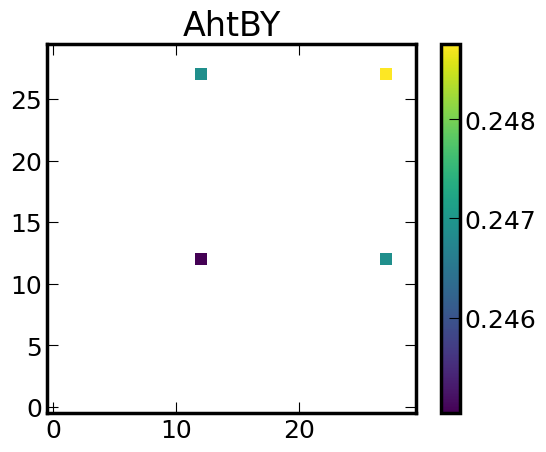

In [169]:
def corr_f(cov):
    err = np.sqrt(np.diag(cov))
    err[err==0] = 1
    err_inv = np.diag(1/err)
    return err_inv@cov@err_inv

diag_inv = np.diag(1/np.append(SCV, ICV))

plt.title("AhtBY")
plt.imshow(diag_inv@covs[1]@diag_inv, origin="lower")
plt.colorbar()
plt.show()

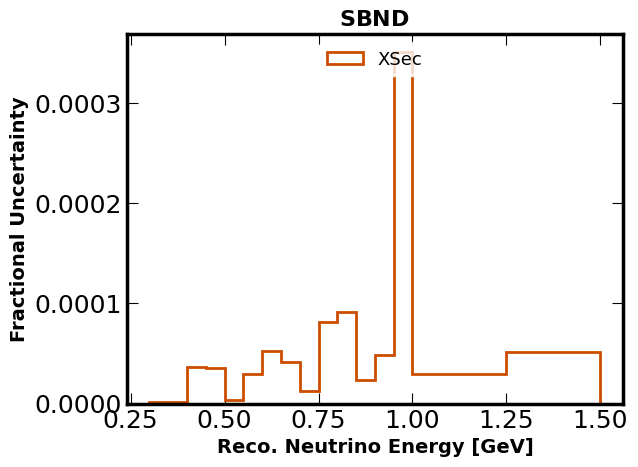

In [94]:
plt.style.use('/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/dune.mplstyle')
for c, l in zip(Scovs, labels):
    if l == "XSec":
        _ = plt.hist(centers, bins=bins, weights=(np.sqrt(np.diag(c))/SCV), label=l, histtype="step", linewidth=2)

add_style(plt.gca(), "Reco. Neutrino Energy [GeV]", det="SBND", ylabel="Fractional Uncertainty", 
          legend_loc="upper center", legend_ncol=2)

plt_text = "SBN Analysis in Progress\nSBND Simulation"
plt_text+="\nNo Detector Syst. Included"
#plt.text(0.75, 0.25, plt_text, fontsize=FONTSIZE+2, zorder=10)
#plt.ylim([0.0001, 0.45])
plt.show()

Text(0.75, 0.25, 'SBN Analysis in Progress\nICARUS Simulation\nNo Detector Syst. Included')

(0.0001, 0.45)

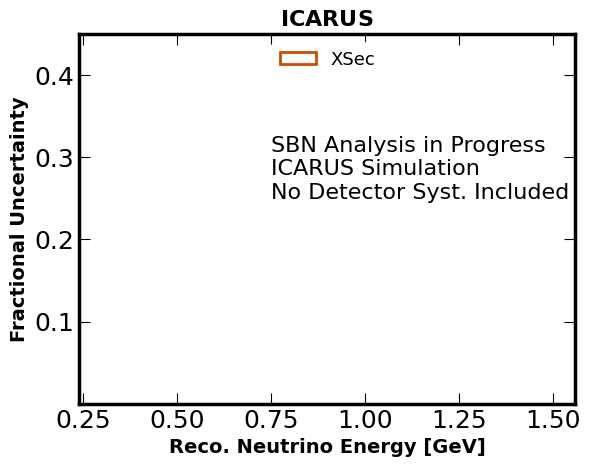

In [89]:
for c, l in zip(Icovs, labels):
    if l == "XSec":
        _ = plt.hist(centers, bins=bins, weights=(np.sqrt(np.diag(c))/ICV), label=l, histtype="step", linewidth=2)

add_style(plt.gca(), "Reco. Neutrino Energy [GeV]", det="ICARUS", ylabel="Fractional Uncertainty", 
          legend_loc="upper center", legend_ncol=2)

plt_text = "SBN Analysis in Progress\nICARUS Simulation"
plt_text+="\nNo Detector Syst. Included"
plt.text(0.75, 0.25, plt_text, fontsize=FONTSIZE+2, zorder=10)
plt.ylim([0.0001, 0.45])
plt.show()

In [83]:
def ratio_cov_full(x, y, cov):
    """
    Covariance of r = x / y given the full covariance of (x, y).

    Parameters
    ----------
    x, y : array-like, shape (n,)
        Central values
    cov : array-like, shape (2n, 2n)
        Full covariance matrix of (x, y)

        Ordering must be:
        cov = [[Cov(x,x), Cov(x,y)],
               [Cov(y,x), Cov(y,y)]]

    Returns
    -------
    cov_r : ndarray, shape (n, n)
        Covariance matrix of r
    """
    n = len(x)
    assert cov.shape == (2*n, 2*n)

    # Protect against division by zero
    eps = 1e-12
    y_safe = np.where(np.abs(y) < eps, eps, y)

    Dx = np.diag(1.0 / y_safe)
    Dy = np.diag(-x / y_safe**2)

    # Full Jacobian: shape (n, 2n)
    J = np.hstack([Dx, Dy])

    return J @ cov @ J.T

In [84]:
ratio = SCV / ICV
ratio_cov_flux = ratio_cov_full(SCV, ICV, covs[0])
ratio_cov_xsec = ratio_cov_full(SCV, ICV, covs[1])
ratio_cov_norm = ratio_cov_full(SCV, ICV, covs[2])
ratio_cov_stat = ratio_cov_full(SCV, ICV, covs[3])
ratio_cov_mcstat = ratio_cov_full(SCV, ICV, covs[4])

ratio_cov_all = ratio_cov_full(SCV, ICV, np.sum(covs, axis=0))

Text(0.7, 0.06, 'SBN Analysis in Progress\nSBN Simulation\nNo Detector Syst. Included')

(0.0001, 0.1)

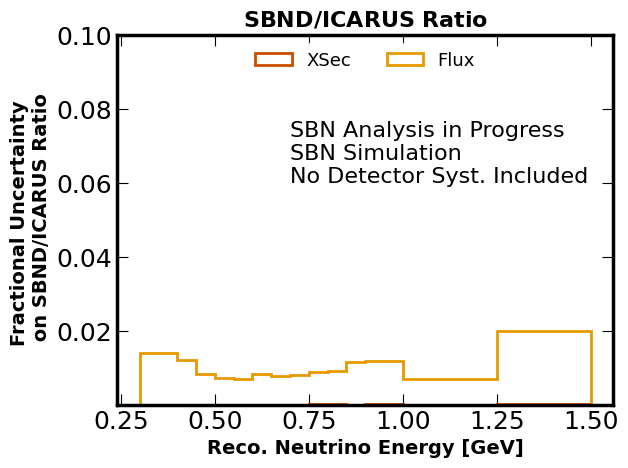

In [85]:
_ = plt.hist(centers, bins=bins, weights=np.sqrt(np.diag(ratio_cov_xsec))/ratio, histtype="step", linewidth=2, label="XSec")
_ = plt.hist(centers, bins=bins, weights=np.sqrt(np.diag(ratio_cov_flux))/ratio, histtype="step", linewidth=2, label="Flux")
add_style(plt.gca(), "Reco. Neutrino Energy [GeV]", title="Ratio", det="SBND / ICARUS", 
          ylabel="Fractional Uncertainty \n on SBND/ICARUS Ratio", legend_loc="upper center", legend_ncol=2)

plt_text = "SBN Analysis in Progress\nSBN Simulation"
plt_text+="\nNo Detector Syst. Included"
plt.text(0.7, 0.06, plt_text, fontsize=FONTSIZE+2)
plt.ylim([0.0001, 0.1])
plt.show()